# **Procesamiento y análisis de señales ECG**

Para la actividad de laboratiorio, en este notebook se implementa algoritmos para el procesamiento y análisis de señales electrocardiográficas (ECG), en donde se realizarán los siguientes acciones: 
- Detección de complejos QRS y picos R
- Detección de ondas P y T
- Análisis de intervalos RR y frecuencia cardíaca

Del mismo modo para la selección de una señal ECG, se escogerá una en específico proviniente de la base de datos brindada en clase ***ECG signals (1000 fragments)***. Referencia de base de datos: https://data.mendeley.com/datasets/7dybx7wyfn/3

## 1. Importación de Librerías

Se importaron las librerías necesarias para el análisis de la señal ECG:
- **neurokit2**: Librería especializada en procesamiento de señales fisiológicas
- **numpy**: Operaciones numéricas y matrices
- **matplotlib**: Visualización de datos
- **pickle**: Lectura de documentos en binario

In [1]:
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
import pickle

## 2. Carga de datos
Se lee mediante la libreria *pickle* el archivo que resume todas las señales extraidas

In [2]:
path_db = "ECG_DATASET/dataset_ekg.pkl"

with open(path_db, "rb") as f:
    dataset = pickle.load(f)

dataset

{'NSR': array([[-0.06451476, -0.05951476, -0.02951476, ...,  0.13548524,
          0.13048524,  0.11548524],
        [ 0.24548524,  0.25048524,  0.24048524, ...,  0.34048524,
          0.33548524,  0.31548524],
        [ 0.13048524,  0.12548524,  0.11048524, ..., -0.20451476,
         -0.20451476, -0.20451476],
        ...,
        [-0.46451476, -0.46451476, -0.46451476, ..., -0.59451476,
         -0.58951476, -0.58951476],
        [-0.53451476, -0.51451476, -0.53451476, ..., -0.51451476,
         -0.44451476, -0.40451476],
        [ 0.51548524,  0.50548524,  0.50548524, ...,  0.21048524,
          0.20048524,  0.18548524]]),
 'VT': array([[ 0.10787069,  0.08787069,  0.08787069, ...,  0.01287069,
         -0.00212931,  0.01787069],
        [-0.31212931, -0.29712931, -0.27212931, ...,  0.82787069,
          0.84787069,  0.86787069],
        [ 0.01287069,  0.00787069,  0.00287069, ...,  0.04787069,
          0.06787069,  0.10287069],
        ...,
        [ 0.17287069,  0.16787069,  0.162

In [3]:
dataset.keys()

dict_keys(['NSR', 'VT', 'IVR', 'VFL', 'Fusion', 'LBBBB', 'RBBBB', 'SDHB', 'PR', 'APB', 'AFL', 'AFIB', 'SVTA', 'WPW', 'PVC', 'Bigeminy', 'Trigeminy'])

### 2.1 Selección de Señal para Análisis

Se selecciona la señal de la fila 6 de la clase PVC (Premature Ventricular Contraction o Contracción Ventricular Prematura).

In [4]:
ecg_signal = dataset["PVC"][6,:]
ecg_signal

array([ 0.29064412,  0.19064412,  0.13064412, ..., -0.08935588,
       -0.09435588, -0.12935588])

In [5]:
ecg_signal.shape

(3600,)

### 2.2 Configuración de Parámetros

Configuramos la frecuencia de muestreode 360Hz usada en el estudio y se define un vector de tiempo.

In [6]:
fs = 360
t = np.arange(ecg_signal.shape[0]) / fs

### 2.3 Visualización de la Señal Real

Graficamos la señal ECG real para observar su morfología y características.

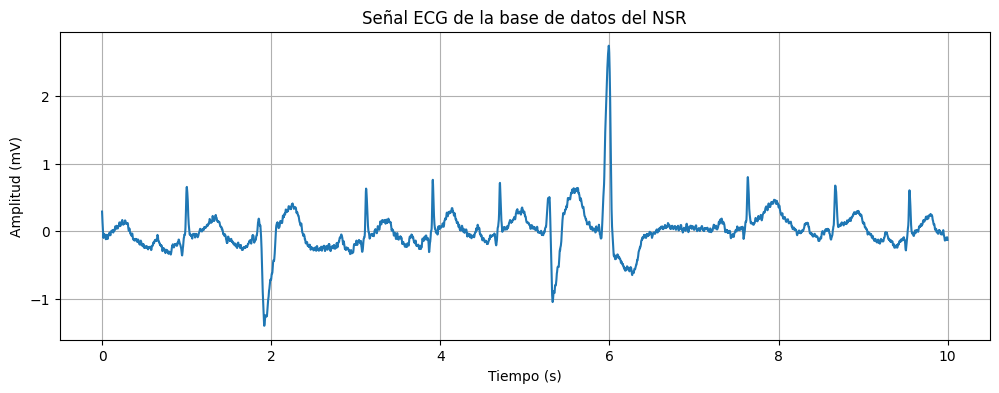

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(t,ecg_signal)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Señal ECG de la base de datos del NSR")
plt.grid()

## 3. Detección de complejos QRS y picos R

Para los algoritmos de detección se van a usar las funciones de la libreria *NeuroKit2*, primero para la detección de los picos R.

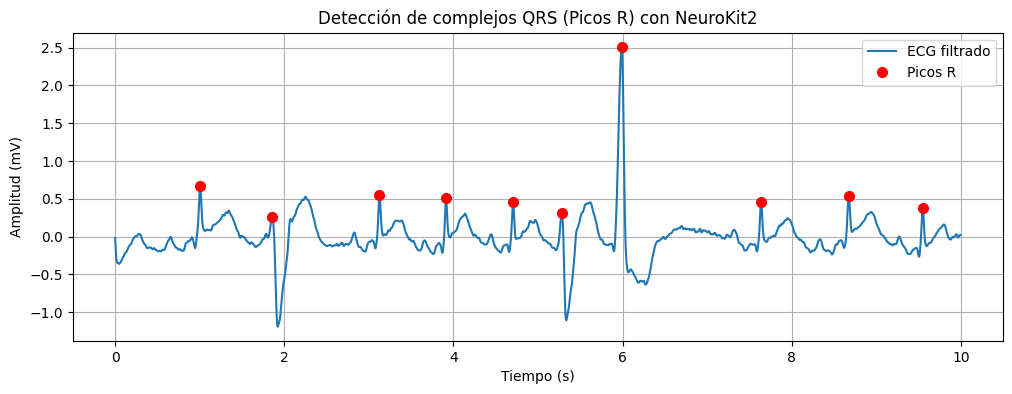

In [8]:
cleaned_ecg = nk.ecg_clean(ecg_signal, sampling_rate=fs, method="neurokit")

# Detección de picos R (QRS)
_, info = nk.ecg_peaks(cleaned_ecg, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]

plt.figure(figsize=(12, 4))
plt.plot(t, cleaned_ecg, label='ECG filtrado')
plt.plot(t[r_peaks], cleaned_ecg[r_peaks], "ro", markersize=7, label='Picos R')

plt.title("Detección de complejos QRS (Picos R) con NeuroKit2")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.legend(loc='upper right')
plt.grid()
plt.show()

## 4. Detección de ondas P y T

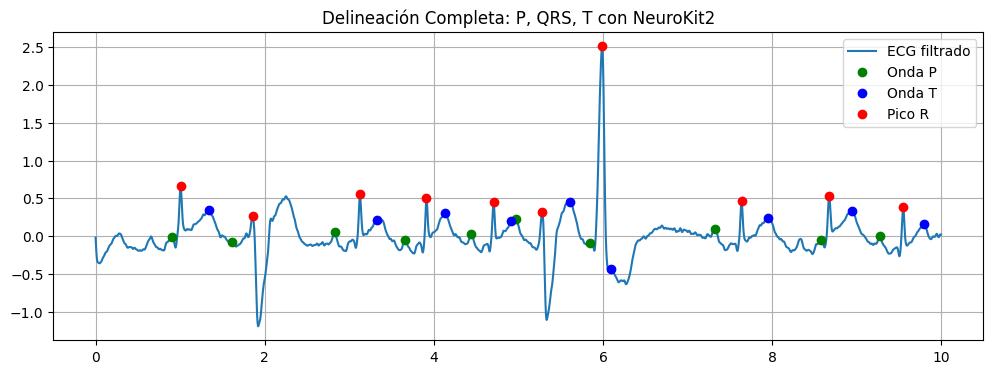

In [9]:
signals, waves_info = nk.ecg_delineate(cleaned_ecg, r_peaks, sampling_rate=fs, method="dwt")

plt.figure(figsize=(12, 4))
plt.plot(t, cleaned_ecg, label='ECG filtrado')
p_peaks = waves_info["ECG_P_Peaks"]
t_peaks = waves_info["ECG_T_Peaks"]

p_peaks = [x for x in p_peaks if not np.isnan(x)]
t_peaks = [x for x in t_peaks if not np.isnan(x)]

# Picos P en Verde
plt.plot(t[np.array(p_peaks, dtype=int)], cleaned_ecg[np.array(p_peaks, dtype=int)],"go", label='Onda P')

# Picos T en Azul
plt.plot(t[np.array(t_peaks, dtype=int)], cleaned_ecg[np.array(t_peaks, dtype=int)],"bo", label='Onda T')

# Picos R en Rojo (referencia)
plt.plot(t[r_peaks], cleaned_ecg[r_peaks], "ro", label='Pico R')

plt.title("Delineación Completa: P, QRS, T con NeuroKit2")
plt.legend(loc='upper right')
plt.grid()
plt.show()

## 5. Análisis de intervalos RR y estimación de frecuencia cardiaca

Calculamos los intervalos RR (tiempo entre picos R consecutivos) y la frecuencia cardíaca instantánea. Estos parámetros son fundamentales para el análisis de la variabilidad del ritmo cardíaco (HRV).

In [10]:
def rr_intervals_ms(r_peaks, fs):
    """Return RR intervals in milliseconds and heart rate series in bpm."""
    if len(r_peaks) < 2:
        return np.array([]), np.array([])
    rr_ms = np.diff(r_peaks) * 1000.0 / fs
    hr_bpm = 60_000.0 / rr_ms
    return rr_ms, hr_bpm


### 5.1 Cálculo de Intervalos RR y Frecuencia Cardíaca

Calculamos los intervalos RR en milisegundos y convertimos a latidos por minuto (bpm).

In [11]:
rr_ms, hr_bpm = rr_intervals_ms(r_peaks, fs)

### 5.2 Visualización de la Frecuencia Cardíaca

Graficamos la frecuencia cardíaca instantánea calculada a partir de los intervalos RR.

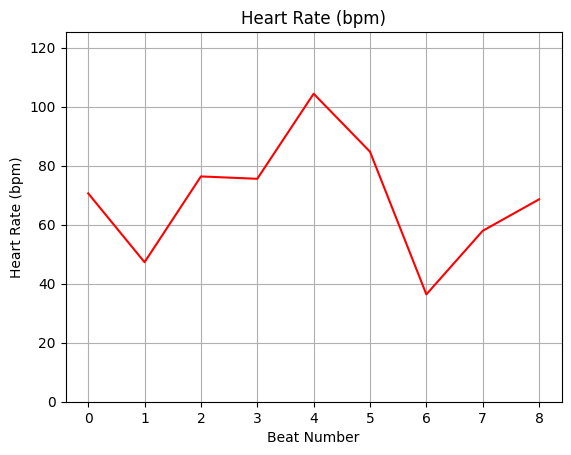

In [12]:
plt.plot(hr_bpm, c='red')
plt.title('Heart Rate (bpm)')
plt.xlabel('Beat Number')
plt.ylabel('Heart Rate (bpm)')
plt.ylim(0, max(hr_bpm)*1.2)
plt.grid()
plt.show()